# Choosing a UMAP Layout Optimizer

There are two broad stages to fitting a UMAP model. First UMAP constructs a weighted nearest-neighbor graph representing the topology of the input data. It then has to find a low dimensional layout of that graph. Most of the familiar UMAP parameters, such as `n_neighbors` and `metric`, primarily affect the first stage. The `optimizer` parameter controls how the layout is improved in the second stage.

Historically UMAP provided a single layout optimizer. Version 0.6 adds two new optimizers, based on Adam and momentum, while retaining the original optimizer for compatibility. In this tutorial we will look at the differences between those choices, how they interact with initialization and DensMAP, and when the more advanced negative sampling options may be useful.

To make the timing differences easier to see we will use the MNIST handwritten digit dataset. This has 70,000 samples, which is large enough for parallel layout optimization to make a meaningful difference.

In [1]:
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import sklearn.datasets
import umap

mnist = sklearn.datasets.fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
)
data = np.ascontiguousarray(mnist.data, dtype=np.float32)
labels = np.asarray(mnist.target, dtype=np.int32)

data.shape, data.dtype, data.flags.c_contiguous

((70000, 784), dtype('float32'), True)

## Warming up the implementations

UMAP uses Numba to compile performance-critical functions. The first call to a particular optimizer in a Python process can therefore include compilation time that later calls do not pay. Since our goal is to compare fit times rather than compilation times, we will first run each optimizer briefly on 5,000 samples. This is large enough to exercise the large-data optimizer kernels, and uses the same number of features and the same data type as the full runs below.

The warm-up fits are deliberately not timed. The timings that follow are consequently warm timings; timings from a fresh process will be longer.

In [2]:
%%capture
warmup_data = np.ascontiguousarray(data[:5000])
umap.UMAP(
    compatibility_layout=True,
    init="spectral",
    optimizer="compatibility",
    n_epochs=20,
    n_jobs=1,
    random_state=42,
).fit(warmup_data)
umap.UMAP(
    compatibility_layout=False,
    init="recursive",
    optimizer="adam",
    n_epochs=20,
    n_jobs=-1,
    random_state=42,
).fit(warmup_data)
umap.UMAP(
    compatibility_layout=False,
    init="recursive",
    optimizer="momentum",
    n_epochs=20,
    n_jobs=-1,
    random_state=42,
).fit(warmup_data)

## The compatibility layout

For the 0.6 release UMAP uses the compatibility layout by default. Thus a standard fit continues to use the layout behavior from earlier releases. Here we set all of the relevant choices explicitly so that the example will continue to mean the same thing after the default changes:

In [3]:
%%time
compatibility_embedding = umap.UMAP(
    compatibility_layout=True,
    init="spectral",
    optimizer="compatibility",
    n_jobs=1,
    random_state=42,
).fit_transform(data)

CPU times: user 1min 30s, sys: 1.71 s, total: 1min 32s
Wall time: 41.9 s


It is worth noting that `compatibility_layout` covers a little more than the final layout optimizer. It also retains the previous nearest-neighbor search settings, and uses the previous spectral initialization in place of the new recursive initialization. This makes it the most convenient choice when an existing application needs to preserve the behavior of earlier UMAP releases.

The compatibility layout will remain available, but it is intended as a transition path rather than the long-term default. Version 0.6 warns that `compatibility_layout` will default to `False` in a future release. Code that relies on the old behavior should therefore request it explicitly.

There is also an `optimizer="compatibility"` setting. This selects the original optimizer, but does not by itself restore the other nearest-neighbor and initialization choices. Conversely, `compatibility_layout=True` takes precedence over `optimizer` and uses the original optimizer as part of the full compatibility path. Usually the broader `compatibility_layout` option is the clearer choice when preserving the behavior of an older model is the goal.

## The Adam optimizer

For new applications the recommended choice is the Adam optimizer. We can try it by turning off the compatibility layout and selecting Adam. We also select recursive initialization explicitly, since this combination is intended to become the default after the transition release.

In [4]:
%%time
with contextlib.redirect_stdout(io.StringIO()):
    adam_embedding = umap.UMAP(
        compatibility_layout=False,
        init="recursive",
        optimizer="adam",
        n_jobs=-1,
        random_state=42,
    ).fit_transform(data)

CPU times: user 1min 49s, sys: 1min 1s, total: 2min 51s
Wall time: 5.63 s


Rather than applying every attractive or repulsive force to the embedding immediately, the new optimizers accumulate forces before updating a point. Adam keeps running estimates of both the size and direction of those forces and uses them to adapt the update made for each coordinate. This makes Adam particularly worth considering for longer optimization runs, where those adaptive updates have more opportunity to refine the layout.

## The momentum optimizer

The other new choice is `optimizer="momentum"`:

In [5]:
%%time
with contextlib.redirect_stdout(io.StringIO()):
    momentum_embedding = umap.UMAP(
        compatibility_layout=False,
        init="recursive",
        optimizer="momentum",
        n_jobs=-1,
        random_state=42,
    ).fit_transform(data)

CPU times: user 1min 50s, sys: 52.3 s, total: 2min 42s
Wall time: 5.66 s


The momentum optimizer carries some of the previous update direction into the next update. This tends to smooth the path taken through the optimization and provides a useful modern alternative to Adam. Adam is the intended default for new work, while momentum is worth comparing on datasets where the optimizer choice matters.

The name `"momentum"` replaces the `"standard"` name used during early development of the new optimizer code. The old name is not accepted.

## Comparing the resulting embeddings

We can now plot the three embeddings side by side. Each optimizer recovers the digit structure, but the coordinates and the arrangement of clusters are different. This is expected: rotations, reflections, and larger changes in the arrangement are all possible when the optimization procedure changes. The useful comparison is whether an embedding preserves the structure that matters for the application, not whether its coordinates match an embedding produced by another optimizer.

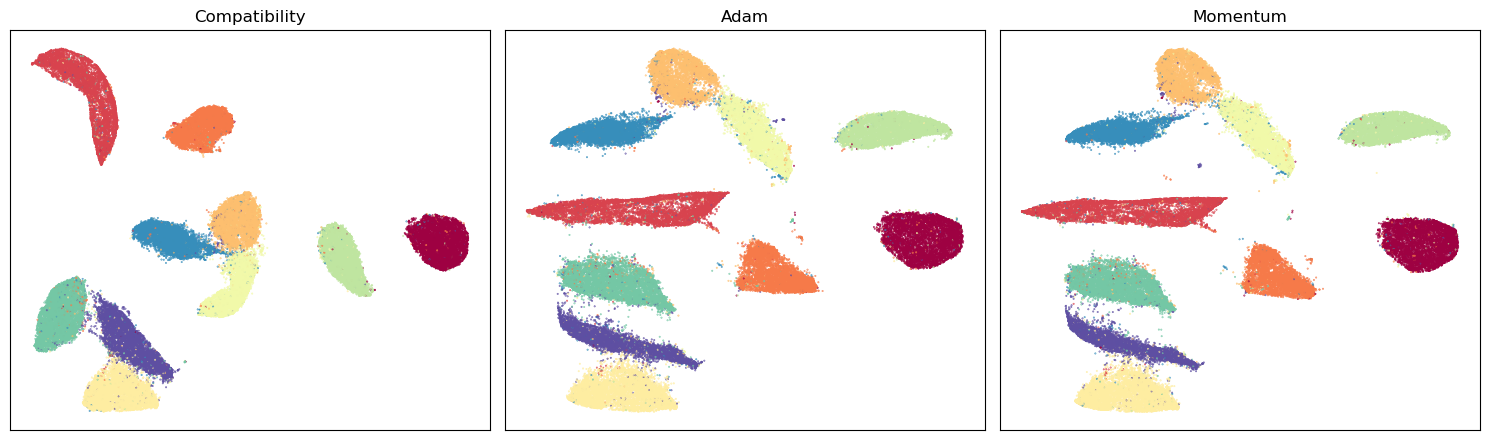

In [6]:
embeddings = [compatibility_embedding, adam_embedding, momentum_embedding]
titles = ["Compatibility", "Adam", "Momentum"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for embedding, title, axis in zip(embeddings, titles, axes):
    axis.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="Spectral",
        s=0.15,
        rasterized=True,
    )
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
plt.tight_layout()
plt.show()

The displayed timings are specific to this machine and dataset, and should not be treated as general benchmark results. They do, however, demonstrate how to make a fair warm comparison. Larger datasets, different numbers of threads, and different values of `n_epochs` can change the relative timings considerably.

These are timings for the complete configurations shown above rather than isolated optimizer kernels. In particular, the compatibility path uses spectral initialization while the modern examples use recursive initialization. The timings therefore answer the practical question of how long each complete fit takes, but should not be used to attribute all of the difference to the optimizer alone.

## Reproducibility and parallelism

One of the major advantages of the new optimizers is that they can make full use of parallel layout optimization even when `random_state` is fixed. A second fit with the same data, parameters, and random state will reproduce an Adam or momentum embedding exactly, while still using the configured Numba threads.

The original optimizer applies updates immediately. If several threads apply those updates at once, the order depends on races between the threads and cannot be reproduced from a random seed. A seeded compatibility fit therefore uses a single thread for layout optimization. When the broader `compatibility_layout=True` option is used with a seed, UMAP currently also sets `n_jobs` to one to preserve the full compatibility path.

This means that the choice is no longer simply between a fast unseeded fit and a slower reproducible fit. With Adam or momentum it is possible to have both parallel layout optimization and exact reproducibility. We can verify that directly by repeating the Adam fit:

In [7]:
%%time
with contextlib.redirect_stdout(io.StringIO()):
    repeated_adam_embedding = umap.UMAP(
        compatibility_layout=False,
        init="recursive",
        optimizer="adam",
        random_state=42,
        n_jobs=-1,
    ).fit_transform(data)

CPU times: user 1min 51s, sys: 56.6 s, total: 2min 47s
Wall time: 5.7 s


In [8]:
np.array_equal(adam_embedding, repeated_adam_embedding)

True

The momentum optimizer has the same reproducibility property. Of course changing optimizers can change the embedding, so we should not expect Adam or momentum coordinates to match those produced by the compatibility layout. The important question is whether the result is stable in the ways that matter for the analysis. The reproducibility tutorial contains a more detailed discussion of random seeds and thread control.

## Recursive initialization

An optimizer does not begin with an empty embedding: it needs a set of initial coordinates to improve. The new `init="recursive"` option first coarsens the fuzzy graph into a much smaller graph. It lays out that graph, expands the result back to the next level, and continues until coordinates have been provided for the original data. This can provide Adam and momentum with a useful starting point without requiring a spectral decomposition of the full graph.

The `recursive_coarsening_ratio` parameter controls how aggressively the graph is reduced at each level. It accepts values of `2`, `3`, or `4`. The default value of `4` is the fastest. Values of `3` and `2` use more coarsening levels, spending additional initialization time in exchange for a more gradual expansion back to the full graph. As with the optimizer itself, the useful comparison will depend on the data and the intended application.

In the release after 0.6, recursive initialization together with Adam is intended to become the default. Specifying both options explicitly makes the intended behavior clear and allows code written during the transition to keep the same behavior across releases.

## Using the new optimizers with DensMAP

DensMAP changes the objective being optimized; it is not itself an optimizer. It can therefore be combined with either Adam or momentum by setting `densmap=True` independently:

In [9]:
dens_mapper = umap.UMAP(
    compatibility_layout=False,
    init="recursive",
    optimizer="adam",
    densmap=True,
    random_state=42,
)

Earlier development versions used composite names such as `"densmap_adam"` and `"densmap_momentum"`. These names are no longer accepted; use `densmap=True` together with `optimizer="adam"` or `optimizer="momentum"` instead. As before, DensMAP requires a Euclidean output metric. The DensMAP tutorial describes the density preservation objective and its parameters in more detail.

## Controlling negative sample selection

UMAP uses negative samples to provide the repulsive forces that prevent an embedding from collapsing. The existing `negative_sample_rate` parameter controls how many negative samples are used, while `repulsion_strength` controls the weight given to them. These remain the main parameters for adjusting repulsion.

The new optimizers also provide some more specialized controls. Most users should leave these at their defaults. They are primarily useful when testing hard-negative selection on large datasets, and should be evaluated on data representative of the final application.

### `negative_selection_range`

By default this is `200000`. For datasets no larger than the selection range all vertices are available as negative samples. On a larger dataset UMAP can instead select from a local window in an ordering of the current embedding. This offers harder negative examples, since candidates in such a window are more likely to lie near the source point in the embedding. Reducing the value makes the selection more local.

### `exclude_graph_neighbors`

With localized negative selection it becomes more likely that a point joined to the source by an attractive graph edge will also be selected as a negative sample. Such a point is a false negative: one part of the objective is trying to pull it closer while another is trying to push it away. Setting `exclude_graph_neighbors=True` prevents graph neighbors, and the source point itself, from receiving negative updates.

### `negative_sample_scale`

Selecting negatives from only part of the data changes the total repulsive force. UMAP normally derives a correction from the selection range. `negative_sample_scale` can be used to supply that multiplier explicitly. This is mainly useful for experiments that need to separate the effect of local negative selection from the effect of changing the repulsive-force scale.

### `negative_sample_scale_adaptation_samples`

When hard-negative selection is active, the Adam optimizer can adapt the negative-sample scale during the first half of optimization. This parameter controls how many sample points are used to estimate that adaptation. The default is `128`; setting it to `0` disables adaptation.

These controls apply only where the corresponding modern layout kernel supports them. The selection range, graph-neighbor exclusion, and explicit scale are available for large Euclidean Adam and momentum layouts, while automatic scale adaptation is specific to Adam. For small Euclidean layouts only graph-neighbor exclusion is applicable. These controls are not used by compatibility layout or DensMAP. For a generic non-Euclidean output metric only `negative_selection_range` is used, with a small force-ranked set of candidates. The defaults are designed to work without any special handling, so changing these values should generally be accompanied by quality and runtime measurements.

## Specialized layout objectives

The optimizer setting applies to fitting a standard UMAP model and to transforming new points with that model. Some related operations have their own optimization problem and therefore retain a specialized implementation. In particular, `inverse_transform` uses a dedicated inverse objective. AlignedUMAP jointly optimizes several embeddings with alignment constraints and does not currently expose the Adam, momentum, or compatibility optimizer choices.

## Migrating existing code

For most existing code the 0.6 compatibility default provides time to test the new implementation before changing behavior. The main mappings for code that used names from development versions are:

In [10]:
# Old development names:
# umap.UMAP(optimizer="standard")
# umap.UMAP(optimizer="densmap_adam")

momentum_reducer = umap.UMAP(
    compatibility_layout=False,
    optimizer="momentum",
)

dens_reducer = umap.UMAP(
    compatibility_layout=False,
    optimizer="adam",
    densmap=True,
)

The removed names are rejected rather than silently translated. Serialized estimators or saved configurations that contain one of them should be updated to the current parameters and the resulting embedding should be checked using the criteria appropriate to the original application.